In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df1 = pd.read_csv("./raw/us-financial-indicators/main.csv", parse_dates=["date"])
df2 = pd.read_csv("./raw/how-financial-crisis-are-born/global_crisis_data.csv")
df2_us = df2[df2["iso3"] == "USA"].copy()
df2_us["year"] = df2_us["year"].astype(int)

df1["year"] = df1["date"].dt.year
df1_anual = df1.groupby("year")[["Interest_Rate","Inflation","GDP",
                                  "Unemployment","Ind_Prod","sp500"]].mean().reset_index()

cols_df2 = ["year","crisis_any","crisis_next_12m","banking_crisis_next_12m",
            "currency_crisis_next_12m","fed_funds_rate","real_interest_rate_10y"]
cols_df2 = [c for c in cols_df2 if c in df2_us.columns]
df_merged = pd.merge(df1_anual, df2_us[cols_df2], on="year", how="inner")

features = ["Interest_Rate", "Inflation", "GDP", "Unemployment", "Ind_Prod", "sp500"]
df_pca = df_merged[features + ["crisis_any", "crisis_next_12m", "year"]].dropna()

X = df_pca[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [3]:
from sklearn.model_selection import train_test_split

X = df_pca[features]
y = df_pca["crisis_next_12m"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

resultados = []

neighbors_list = [3, 5, 7, 9, 11, 15]
weights_list = ['uniform', 'distance']
metrics_list = ['euclidean', 'manhattan']

for n in neighbors_list:
    for w in weights_list:
        for m in metrics_list:
            
            model = KNeighborsClassifier(
                n_neighbors=n,
                weights=w,
                metric=m
            )
            
            scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
            
            resultados.append({
                "n_neighbors": n,
                "weights": w,
                "metric": m,
                "f1_mean": scores.mean()
            })

df_resultados = pd.DataFrame(resultados)

print(df_resultados.sort_values(by="f1_mean", ascending=False))

best_row = df_resultados.sort_values(by="f1_mean", ascending=False).iloc[0]

    n_neighbors   weights     metric   f1_mean
1             3   uniform  manhattan  0.693333
3             3  distance  manhattan  0.653333
6             5  distance  euclidean  0.620000
4             5   uniform  euclidean  0.620000
10            7  distance  euclidean  0.620000
0             3   uniform  euclidean  0.600000
11            7  distance  manhattan  0.580000
2             3  distance  euclidean  0.560000
23           15  distance  manhattan  0.533333
22           15  distance  euclidean  0.533333
14            9  distance  euclidean  0.533333
15            9  distance  manhattan  0.533333
18           11  distance  euclidean  0.533333
19           11  distance  manhattan  0.533333
9             7   uniform  manhattan  0.526667
8             7   uniform  euclidean  0.526667
7             5  distance  manhattan  0.520000
5             5   uniform  manhattan  0.520000
12            9   uniform  euclidean  0.213333
13            9   uniform  manhattan  0.213333
16           

In [5]:
print("Melhor configuração (Precisão + Acurácia):")
print(best_row)

Melhor configuração (Precisão + Acurácia):
n_neighbors            3
weights          uniform
metric         manhattan
f1_mean         0.693333
Name: 1, dtype: object


In [6]:
best_knn = KNeighborsClassifier(
    n_neighbors=int(best_row["n_neighbors"]),
    weights=best_row["weights"],
    metric=best_row["metric"]
)

best_knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [7]:
from sklearn.metrics import classification_report

y_pred_test = best_knn.predict(X_test)

print("Relatório:")
print(classification_report(y_test, y_pred_test))

Relatório:
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95        11
         1.0       0.67      1.00      0.80         2

    accuracy                           0.92        13
   macro avg       0.83      0.95      0.88        13
weighted avg       0.95      0.92      0.93        13



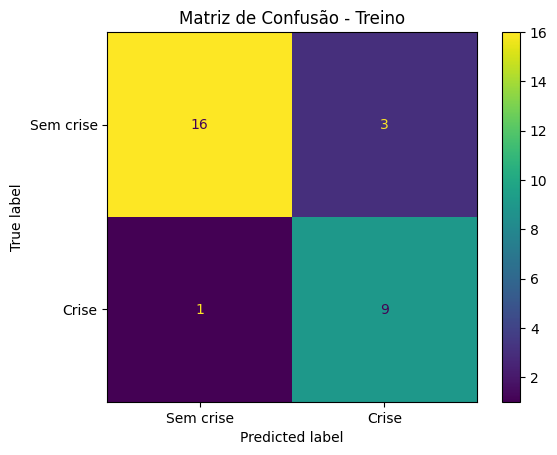

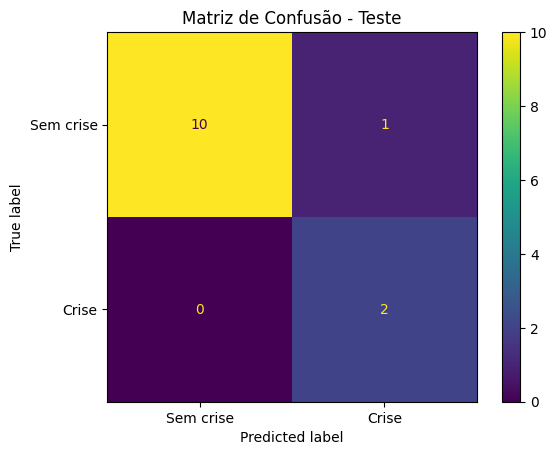

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_train = best_knn.predict(X_train)
cm_train = confusion_matrix(y_train, y_pred_train)

disp = ConfusionMatrixDisplay(cm_train, display_labels=["Sem crise", "Crise"])
disp.plot()
plt.title("Matriz de Confusão - Treino")
plt.show()

y_pred_test = best_knn.predict(X_test)
cm_test = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(cm_test, display_labels=["Sem crise", "Crise"])
disp.plot()
plt.title("Matriz de Confusão - Teste")
plt.show()